In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.shape

(15000, 21)

In [8]:
df.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       85990, 85991, 85992, 85993, 85994, 85995, 85996, 85997, 85998, 85999],
      dtype='int64', length=15000)

In [9]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [10]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
select = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre']
df = df[select]
df.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [18]:
df.track_genre.value_counts().head(15)

track_genre
acoustic             1000
metal                1000
metalcore            1000
minimal-techno       1000
mpb                  1000
new-age              1000
opera                1000
pagode               1000
party                1000
piano                1000
pop-film             1000
pop                  1000
power-pop            1000
progressive-house    1000
punk-rock            1000
Name: count, dtype: int64

In [20]:
top_genres = df["track_genre"].value_counts().head(15).index

df = df[df["track_genre"].isin(top_genres)]

In [21]:
df['track_genre'].nunique()

15

In [24]:
df.describe().sum()

popularity          1.528112e+04
duration_ms         6.301342e+06
danceability        1.500329e+04
energy              1.500394e+04
key                 1.503475e+04
loudness            1.493160e+04
mode                1.500413e+04
speechiness         1.500110e+04
acousticness        1.500255e+04
instrumentalness    1.500156e+04
liveness            1.500198e+04
valence             1.500298e+04
tempo               1.573335e+04
time_signature      1.502132e+04
dtype: float64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 85999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        15000 non-null  int64  
 1   duration_ms       15000 non-null  int64  
 2   explicit          15000 non-null  bool   
 3   danceability      15000 non-null  float64
 4   energy            15000 non-null  float64
 5   key               15000 non-null  int64  
 6   loudness          15000 non-null  float64
 7   mode              15000 non-null  int64  
 8   speechiness       15000 non-null  float64
 9   acousticness      15000 non-null  float64
 10  instrumentalness  15000 non-null  float64
 11  liveness          15000 non-null  float64
 12  valence           15000 non-null  float64
 13  tempo             15000 non-null  float64
 14  time_signature    15000 non-null  int64  
 15  track_genre       15000 non-null  object 
dtypes: bool(1), float64(9), int64(5), object(1)
m

In [30]:
corre = df.corr(numeric_only=True)
print("Correlation of numeric features:",corre)

Correlation of numeric features:                   popularity  duration_ms  explicit  danceability    energy  \
popularity          1.000000     0.011055  0.062617      0.105736  0.007776   
duration_ms         0.011055     1.000000 -0.053284      0.001329 -0.064718   
explicit            0.062617    -0.053284  1.000000     -0.007784  0.177401   
danceability        0.105736     0.001329 -0.007784      1.000000  0.272197   
energy              0.007776    -0.064718  0.177401      0.272197  1.000000   
key                 0.002768     0.007978 -0.002848      0.029716  0.045413   
loudness            0.047501    -0.096315  0.153503      0.305162  0.836413   
mode               -0.076171    -0.058032 -0.016720     -0.061146 -0.082238   
speechiness        -0.006286    -0.076948  0.178863      0.068103  0.286979   
acousticness        0.001191    -0.008023 -0.166981     -0.330005 -0.819316   
instrumentalness   -0.093819     0.227576 -0.097362     -0.119708 -0.402292   
liveness           

In [ ]:
# EDA

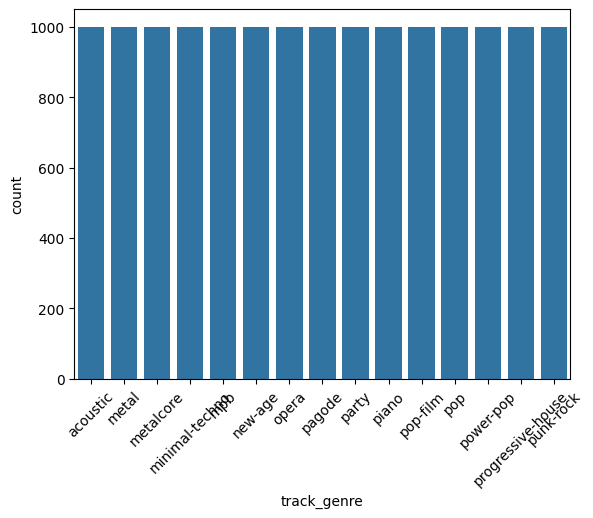

In [40]:
sns.countplot(data = df, x = 'track_genre')
plt.xticks(rotation = 45)
plt.show()

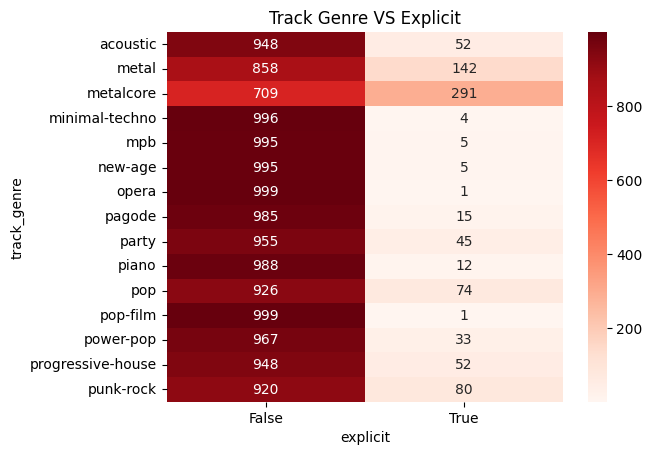

In [44]:
sns.heatmap(pd.crosstab(df['track_genre'],df['explicit']),annot = True,fmt = "d",cmap = "Reds")
plt.title("Track Genre VS Explicit")
plt.show()

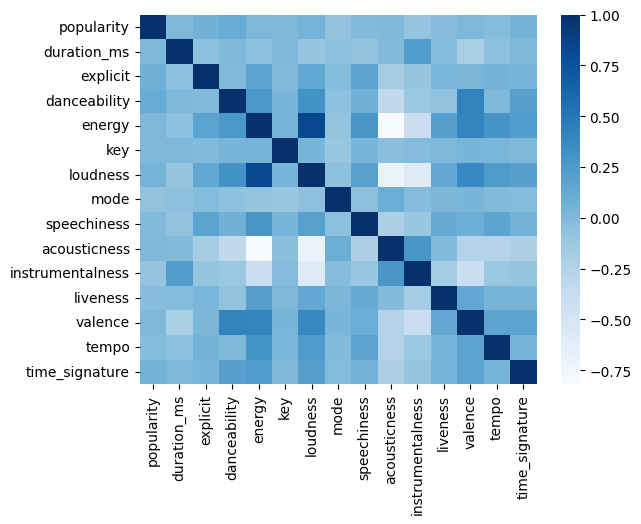

In [51]:
sns.heatmap(corre,annot = False,cmap = "Blues")
plt.show()

In [53]:
# Feature Selection
X = df.drop('track_genre',axis = 1)
y = df['track_genre']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,stratify = y,random_state = 42)

In [54]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13500, 15)
(1500, 15)
(13500,)
(1500,)


In [56]:
# Encoding

#LabelEncoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [62]:
#OneHotEncoding

ohe = OneHotEncoder(sparse_output = False,handle_unknown = "ignore")
encoded_train = ohe.fit_transform(X_train[["explicit"]])
encoded_test = ohe.transform(X_test[["explicit"]])

#Converting to dataframe
encoded_train = pd.DataFrame(
    encoded_train,
    columns=ohe.get_feature_names_out(["explicit"]),
    index=X_train.index
)

encoded_test = pd.DataFrame(
    encoded_test,
    columns=ohe.get_feature_names_out(["explicit"]),
    index=X_test.index
)


# The obtained train and test
X_train_new = X_train.drop("explicit", axis=1)
X_test_new = X_test.drop("explicit", axis=1)

X_train_new = pd.concat([X_train_new, encoded_train], axis=1)
X_test_new = pd.concat([X_test_new, encoded_test], axis=1)

In [63]:
X_train_new.head()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,explicit_False,explicit_True
81960,85,211466,0.358,0.5570,10,-7.398,1,0.0590,0.695,0.000000,0.0902,0.494,85.043,4,1.0,0.0
581,51,236379,0.657,0.4300,1,-10.202,1,0.0314,0.534,0.000238,0.1200,0.335,91.967,4,1.0,0.0
80702,59,377000,0.798,0.6360,6,-10.520,1,0.0431,0.327,0.000000,0.1280,0.799,139.980,4,1.0,0.0
80232,65,342023,0.523,0.6740,8,-4.832,0,0.0328,0.771,0.000000,0.1390,0.239,114.058,4,1.0,0.0
75213,36,159661,0.450,0.0709,2,-29.773,1,0.0378,0.994,0.907000,0.1080,0.351,110.822,4,1.0,0.0


In [65]:
y_train

array([10,  0, 11, ...,  6,  6,  7], shape=(13500,))

In [ ]:
# ADA Boost

In [66]:
from sklearn.ensemble import AdaBoostClassifier

In [87]:
adamodel = AdaBoostClassifier(n_estimators = 100,learning_rate = 1)
adamodel.fit(X_train_new,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1
,algorithm,'deprecated'
,random_state,None


In [88]:
y_preda = adamodel.predict(X_test_new)

In [70]:
#Gradient Boost

In [71]:
from sklearn.ensemble import GradientBoostingClassifier

In [74]:
gradmodel = GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1,max_depth = 3)
gradmodel.fit(X_train_new,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [75]:
y_predg = gradmodel.predict(X_test_new)

In [ ]:
# XG Boost

In [78]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.9 MB/s eta 0:00:24
    --------------------------------------- 1.3/69.5 MB 2.7 MB/s eta 0:00:26
   - -------------------------------------- 2.1/69.5 MB 2.8 MB/s eta 0:00:24
   - -------------------------------------- 2.6/69.5 MB 2.9 MB/s eta 0:00:24
   - -------------------------------------- 3.4/69.5 MB 3.0 MB/s eta 0:00:23
   -- ------------------------------------- 4.2/69.5 MB 3.1 MB/s eta 0:00:22
   -- ------------------------------------- 4.7/69.5 MB 3.1 MB/s eta 0:00:22
   --- ------------------------------------ 5.5/69.5 MB 3.1 MB/s eta 0:00:21
   --- ------------------------------------ 6.3/69.5 MB 3.2 MB/s eta 0:00:20
   ---- ----------------------------------- 7.1/69.5 MB 3.2 MB/s eta 0:00:20
   ---- ----------------------------------- 7.6/69.5 MB 3.2 MB/s eta 0:00:20
   ---- -----

In [79]:
from xgboost import XGBClassifier
modelx = XGBClassifier(n_estimators = 100,learning_rate = 1,max_depth = 3)
modelx.fit(X_train_new, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [80]:
y_predx = modelx.predict(X_test_new)

In [81]:
# Checking the accuracy

In [82]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,confusion_matrix

In [89]:
print("ADA Boost: ",accuracy_score(y_test,y_preda))
print("Gradient Boost: ",accuracy_score(y_test,y_predg))
print("XG Boost: ",accuracy_score(y_test,y_predx))

ADA Boost:  0.4593333333333333
Gradient Boost:  0.7066666666666667
XG Boost:  0.6993333333333334


In [94]:
print("ADA Boost: ",f1_score(y_test,y_preda,average="weighted"))
print("Gradient Boost: ",f1_score(y_test,y_predg,average="weighted"))
print("XG Boost: ",f1_score(y_test,y_predx,average="weighted"))

ADA Boost:  0.444368493341182
Gradient Boost:  0.7046906366238085
XG Boost:  0.6990641735749479


In [99]:
print("ADA Boost: ",confusion_matrix(y_test,y_preda))
print("Gradient Boost: ",confusion_matrix(y_test,y_predg))
print("XG Boost: ",confusion_matrix(y_test,y_predx))

ADA Boost:  [[51  1  1  0  3  3  7  0  2  3  1 18  5  1  4]
 [ 0 44 21  0  1  0  2  0  0  2  4  4  5  9  8]
 [ 0 31 47  0  0  0  1  0  2  0  0  1  7  2  9]
 [ 0  2  2 83  1  1  0  0  2  0  0  0  0  9  0]
 [52  0  0  0 22  2  2  1  0  1  1  0  7  5  7]
 [ 7  0  0  2  0 55 33  0  0  1  0  0  1  0  1]
 [12  1  3  0  0 10 64  0  0  3  0  1  4  0  2]
 [63  0  0  0  6  0  0 18  4  0  0  4  1  0  4]
 [ 5  3  0  0  0  0  0  0 58  0  0  1 20 12  1]
 [10  3  0  2  1 34  2  0  8 15  3 16  3  2  1]
 [ 3  7  2  0  0  0  6  0 20  3 21 35  0  3  0]
 [ 7  1  0  0  1  0  3  0  0  4  9 68  0  7  0]
 [ 4  1  4  0  2  1  0  0  7  0  1  2 73  3  2]
 [ 1 13  3 20  1  0  0  0  5  1  4  6  1 33 12]
 [ 6  9 10  1  5  0  2  0  6  0  0  2  5 17 37]]
Gradient Boost:  [[60  0  1  2 10  3  4  2  2  2  6  4  0  2  2]
 [ 0 67 10  0  0  0  0  0  1  0  7  1  1  5  8]
 [ 0 14 70  0  0  0  0  0  1  0  1  0  3  8  3]
 [ 0  1  0 91  1  1  0  0  0  0  1  0  0  5  0]
 [ 7  0  0  0 72  1  1 12  0  0  0  1  0  1  5]
 [ 3  0  0

In [101]:
print("ADA Boost: ",classification_report(y_test,y_preda))
print("Gradient Boost: ",classification_report(y_test,y_predg))
print("XG Boost: ",classification_report(y_test,y_predx))

ADA Boost:                precision    recall  f1-score   support

           0       0.23      0.51      0.32       100
           1       0.38      0.44      0.41       100
           2       0.51      0.47      0.49       100
           3       0.77      0.83      0.80       100
           4       0.51      0.22      0.31       100
           5       0.52      0.55      0.53       100
           6       0.52      0.64      0.58       100
           7       0.95      0.18      0.30       100
           8       0.51      0.58      0.54       100
           9       0.45      0.15      0.23       100
          10       0.48      0.21      0.29       100
          11       0.43      0.68      0.53       100
          12       0.55      0.73      0.63       100
          13       0.32      0.33      0.33       100
          14       0.42      0.37      0.39       100

    accuracy                           0.46      1500
   macro avg       0.50      0.46      0.44      1500
weighted avg  

## Conclusion
Among the three boosting algorithms, Gradient Boosting achieved the best performance with an accuracy of 70.67%, closely followed by XGBoost at 69.93%. AdaBoost obtained an accuracy of 45.93%, indicating that it was less effective for this multi-class music genre classification task. Overall, Gradient Boosting was the most suitable model for this dataset under the current preprocessing and default hyperparameter settings.